# Exploratory Data Analysis (EDA) 

This notebook examines the distribution of VAS-derived migraine
severity and explores associations between physiological,
environmental, lifestyle, and temporal predictors and migraine
severity. Only observations meeting ICHD-3 criteria for migraine
and containing a valid VAS-derived severity label are included.

### Load Cleaned Data

In [1]:
from pathlib import Path
import sys

# The notebook is stored inside THESIS/Notebooks,
# so its parent directory is the project root.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\rebec\Documents\Thesis


In [2]:
Path.cwd()

WindowsPath('c:/Users/rebec/Documents/Thesis/Notebooks')

### Import Libraries and Configuration

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import (
    CLEAN_DATA_FILE,
    TARGET,
    MIGRAINE_FILTER,
    SEVERITY_ORDER,
    PHYSIOLOGICAL_BINARY_FEATURES,
    PHYSIOLOGICAL_ORDINAL_FEATURES,
    ENVIRONMENTAL_BINARY_FEATURES,
    LIFESTYLE_BINARY_FEATURES,
    TEMPORAL_FEATURES,
    WEATHER_FEATURES,
    FEATURE_GROUPS,
    FEATURE_SETS,
    RANDOM_STATE,
)

from src.eda_utils import (
    validate_binary_columns,
    create_binary_prevalence_table,
    plot_binary_prevalence,
    create_ordinal_percentage_table,
)

from src.eda_utils import plot_grouped_binary_prevalence

from src.eda_utils import (
    analyze_binary_associations,
    add_benjamini_hochberg_correction,
)

### Load Cleaned Data

In [4]:
diary = pd.read_csv(CLEAN_DATA_FILE)

print(f"Rows: {diary.shape[0]}")
print(f"Columns: {diary.shape[1]}")

Rows: 4544
Columns: 38


### Reapply Categorical Ordering

In [5]:
diary[TARGET] = pd.Categorical(
    diary[TARGET],
    categories=SEVERITY_ORDER,
    ordered=True,
)

### Create Modeling Dataset

Applying inclusion criteria of:
- having a migraine
- VAS score of severity is present

Make copy

**This will be the actual dataset I will train my models on**

In [6]:
model_df = diary.loc[
    (diary[MIGRAINE_FILTER] == 1)
    & diary[TARGET].notna()
].copy()

model_df = model_df.reset_index(drop=True)

print(f"Modeling observations: {model_df.shape[0]}")
print(model_df[TARGET].value_counts().sort_index())

Modeling observations: 302
Severity_VAS
Mild         55
Moderate    138
Severe      109
Name: count, dtype: int64


## Validate Resuable Feature Definitions

### Confirm every configured feature exists

In [7]:
configured_features = {
    feature
    for feature_list in FEATURE_GROUPS.values()
    for feature in feature_list
}

missing_features = sorted(
    configured_features - set(model_df.columns)
)

if missing_features:
    print("Configured features missing from model_df:")
    for feature in missing_features:
        print(f"  - {feature}")
else:
    print("All configured features were found.")

All configured features were found.


### Check whether variables appear in multiple groups

In [8]:
all_grouped_features = [
    feature
    for feature_list in FEATURE_GROUPS.values()
    for feature in feature_list
]

duplicate_assignments = sorted({
    feature
    for feature in all_grouped_features
    if all_grouped_features.count(feature) > 1
})

if duplicate_assignments:
    print("Features assigned to multiple groups:")
    for feature in duplicate_assignments:
        print(f"  - {feature}")
else:
    print("No duplicate feature assignments.")

No duplicate feature assignments.


### Check whether variables appear in multiple groups

In [9]:
all_binary_features = (
    PHYSIOLOGICAL_BINARY_FEATURES
    + ENVIRONMENTAL_BINARY_FEATURES
    + LIFESTYLE_BINARY_FEATURES
)

binary_problems = validate_binary_columns(
    model_df,
    all_binary_features,
)

if binary_problems:
    binary_problems
else:
    print("All binary features contain only 0 and 1.")

All binary features contain only 0 and 1.


## "Actual" EDA

### Examining Target Distribution

In [10]:
severity_counts = (
    model_df[TARGET]
    .value_counts()
    .reindex(SEVERITY_ORDER)
)

severity_percentages = (
    model_df[TARGET]
    .value_counts(normalize=True)
    .reindex(SEVERITY_ORDER)
    .mul(100)
    .round(2)
)

severity_summary = pd.DataFrame({
    "Count": severity_counts,
    "Percentage": severity_percentages,
})

severity_summary

,Count,Percentage
Severity_VAS,,
Mild,55,18.21
Moderate,138,45.70
Severe,109,36.09


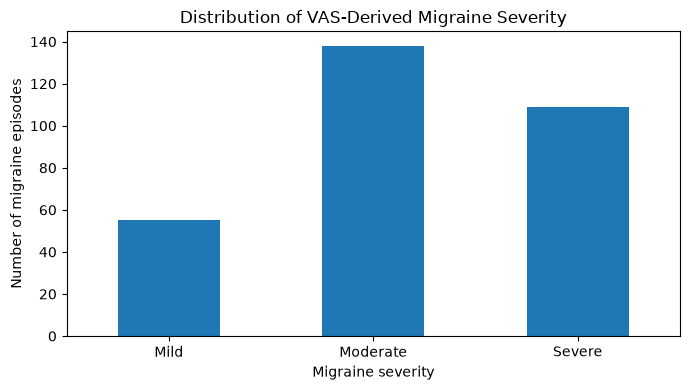

In [11]:
figure, axis = plt.subplots(figsize=(7, 4))

severity_counts.plot(
    kind="bar",
    ax=axis,
)

axis.set_title("Distribution of VAS-Derived Migraine Severity")
axis.set_xlabel("Migraine severity")
axis.set_ylabel("Number of migraine episodes")
axis.tick_params(axis="x", rotation=0)

figure.tight_layout()
plt.show()

### Physiological Prevelence Table

In [12]:
physiological_prevalence = create_binary_prevalence_table(
    data = model_df,
    variables = PHYSIOLOGICAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

physiological_prevalence.head(15)

,Feature,Severity,Percent Present
0,Preventive Medication Use,Mild,36.36
1,Preventive Medication Use,Moderate,54.35
2,Preventive Medication Use,Severe,52.29
3,Internal Factor: Stress,Mild,32.73
4,Internal Factor: Stress,Moderate,44.20
5,Internal Factor: Stress,Severe,30.28
6,Internal Factor: Oversleeping,Mild,3.64
7,Internal Factor: Oversleeping,Moderate,1.45
8,Internal Factor: Oversleeping,Severe,1.83
9,Internal Factor: Sleep Deprivation,Mild,20.00


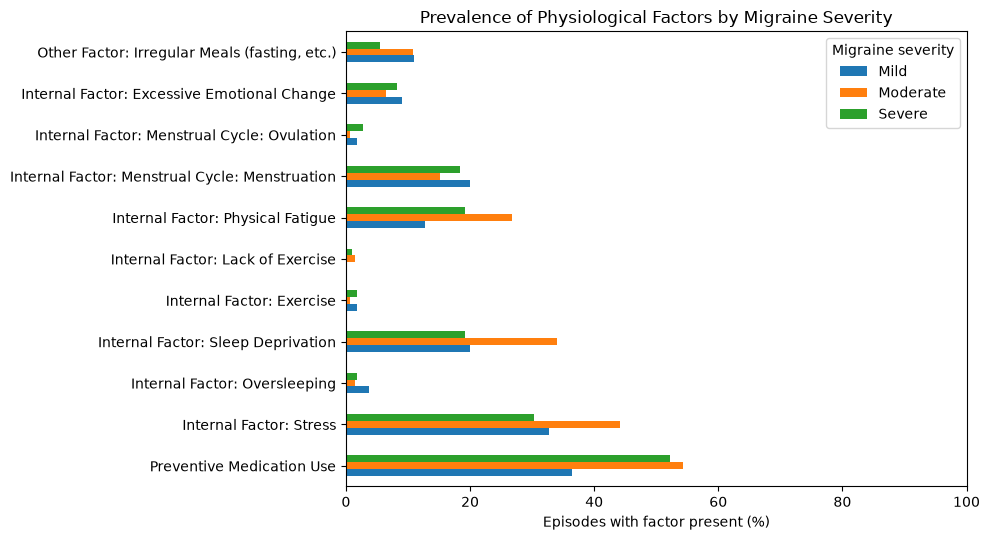

,Mild,Moderate,Severe
Feature,,,
Preventive Medication Use,36.36,54.35,52.29
Internal Factor: Stress,32.73,44.20,30.28
Internal Factor: Oversleeping,3.64,1.45,1.83
Internal Factor: Sleep Deprivation,20.00,34.06,19.27
Internal Factor: Exercise,1.82,0.72,1.83
Internal Factor: Lack of Exercise,0.00,1.45,0.92
Internal Factor: Physical Fatigue,12.73,26.81,19.27
Internal Factor: Menstrual Cycle: Menstruation,20.00,15.22,18.35
Internal Factor: Menstrual Cycle: Ovulation,1.82,0.72,2.75


In [13]:
physiological_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = PHYSIOLOGICAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "Physiological Factors",
)

physiological_prevalence_wide.round(2)

### Total Exercise Analysis

Nominal (categorical) data

In [14]:
total_exercise_table = create_ordinal_percentage_table(
    data = model_df,
    variable = "Total Exercise",
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

total_exercise_table.round(2)

Total Exercise,0,1,2
Severity_VAS,,,
Mild,1.82,14.55,83.64
Moderate,1.45,15.94,82.61
Severe,3.67,10.09,86.24


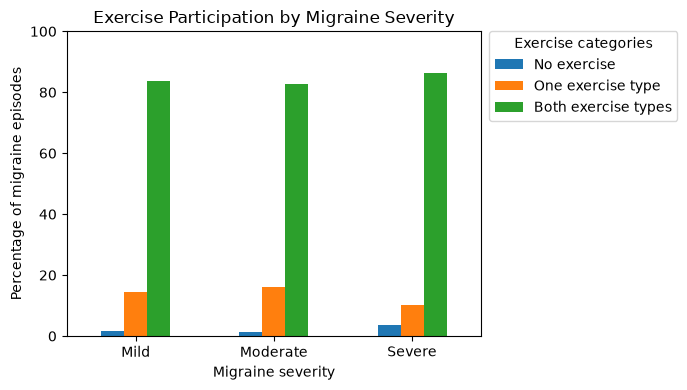

In [15]:
figure, axis = plt.subplots(figsize=(7, 4))

total_exercise_table.plot(
    kind = "bar",
    ax = axis,
)

axis.set_title("Exercise Participation by Migraine Severity")
axis.set_xlabel("Migraine severity")
axis.set_ylabel("Percentage of migraine episodes")
axis.set_ylim(0, 100)
axis.tick_params(axis="x", rotation=0)

axis.legend(
    title = "Exercise categories",
    labels = [
        "No exercise",
        "One exercise type",
        "Both exercise types",
    ],
    loc = "upper left",  # Anchor point of the legend box
    bbox_to_anchor=(1.02, 1),  # Places legend just outside the right boundary (x=1.02, y=1)
    borderaxespad=0
)

figure.tight_layout()
plt.show()

### Environmental Binary Analysis

In [16]:
environmental_prevalence = create_binary_prevalence_table(
    data = model_df,
    variables = ENVIRONMENTAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

environmental_prevalence

,Feature,Severity,Percent Present
0,External Factor: Excessive Sunlight,Mild,0.00
1,External Factor: Excessive Sunlight,Moderate,0.72
2,External Factor: Excessive Sunlight,Severe,2.75
3,External Factor: Noise,Mild,1.82
4,External Factor: Noise,Moderate,10.14
5,External Factor: Noise,Severe,8.26
6,External Factor: Inappropriate Lighting,Mild,0.00
7,External Factor: Inappropriate Lighting,Moderate,0.72
8,External Factor: Inappropriate Lighting,Severe,2.75
9,"External Factor: Specific Smell (cosmetics, pe...",Mild,3.64


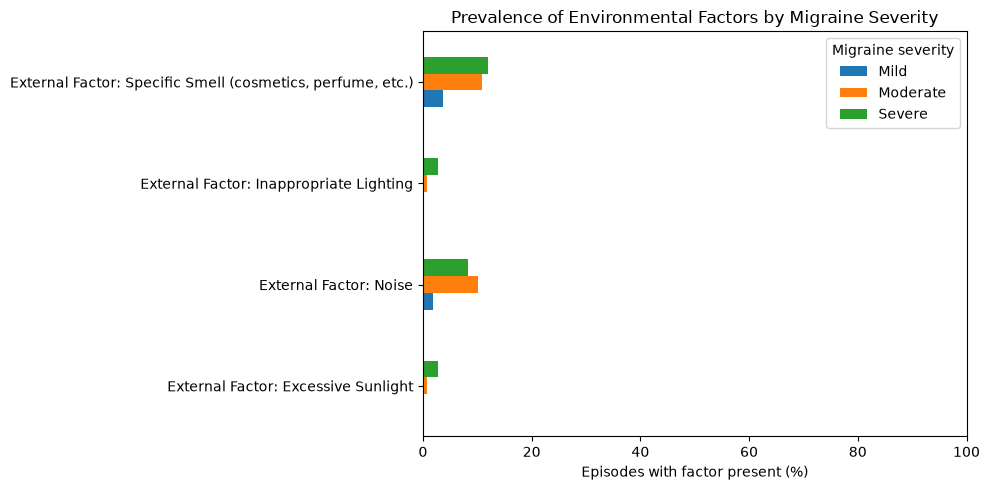

,Mild,Moderate,Severe
Feature,,,
External Factor: Excessive Sunlight,0.00,0.72,2.75
External Factor: Noise,1.82,10.14,8.26
External Factor: Inappropriate Lighting,0.00,0.72,2.75
"External Factor: Specific Smell (cosmetics, perfume, etc.)",3.64,10.87,11.93


In [17]:
binary_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = ENVIRONMENTAL_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "Environmental Factors",
)

binary_prevalence_wide.round(2)

### Lifestyle Binary Analysis

In [18]:
lifestyle_prevalence = create_binary_prevalence_table(
    data = model_df,
    variables = LIFESTYLE_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER
)

lifestyle_prevalence

,Feature,Severity,Percent Present
0,Other Factor: Excessive Alcohol,Mild,5.45
1,Other Factor: Excessive Alcohol,Moderate,7.25
2,Other Factor: Excessive Alcohol,Severe,7.34
3,Other Factor: Overeating,Mild,5.45
4,Other Factor: Overeating,Moderate,2.90
5,Other Factor: Overeating,Severe,6.42
6,Other Factor: Excessive Caffeine,Mild,0.00
7,Other Factor: Excessive Caffeine,Moderate,0.72
8,Other Factor: Excessive Caffeine,Severe,4.59
9,Other Factor: Excessive Smoking,Mild,1.82


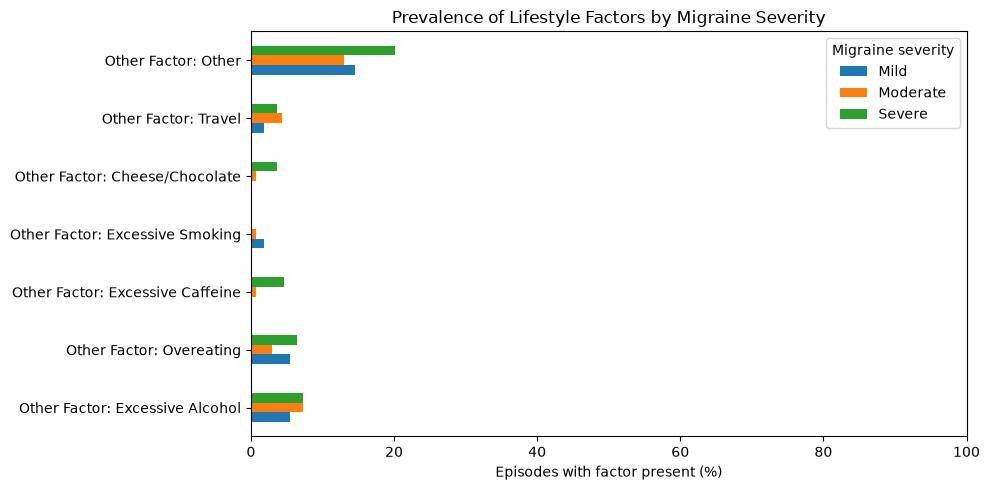

,Mild,Moderate,Severe
Feature,,,
Other Factor: Excessive Alcohol,5.45,7.25,7.34
Other Factor: Overeating,5.45,2.90,6.42
Other Factor: Excessive Caffeine,0.00,0.72,4.59
Other Factor: Excessive Smoking,1.82,0.72,0.00
Other Factor: Cheese/Chocolate,0.00,0.72,3.67
Other Factor: Travel,1.82,4.35,3.67
Other Factor: Other,14.55,13.04,20.18


In [19]:
binary_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = LIFESTYLE_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "Lifestyle Factors",
)

binary_prevalence_wide.round(2)

### All Binary Factors

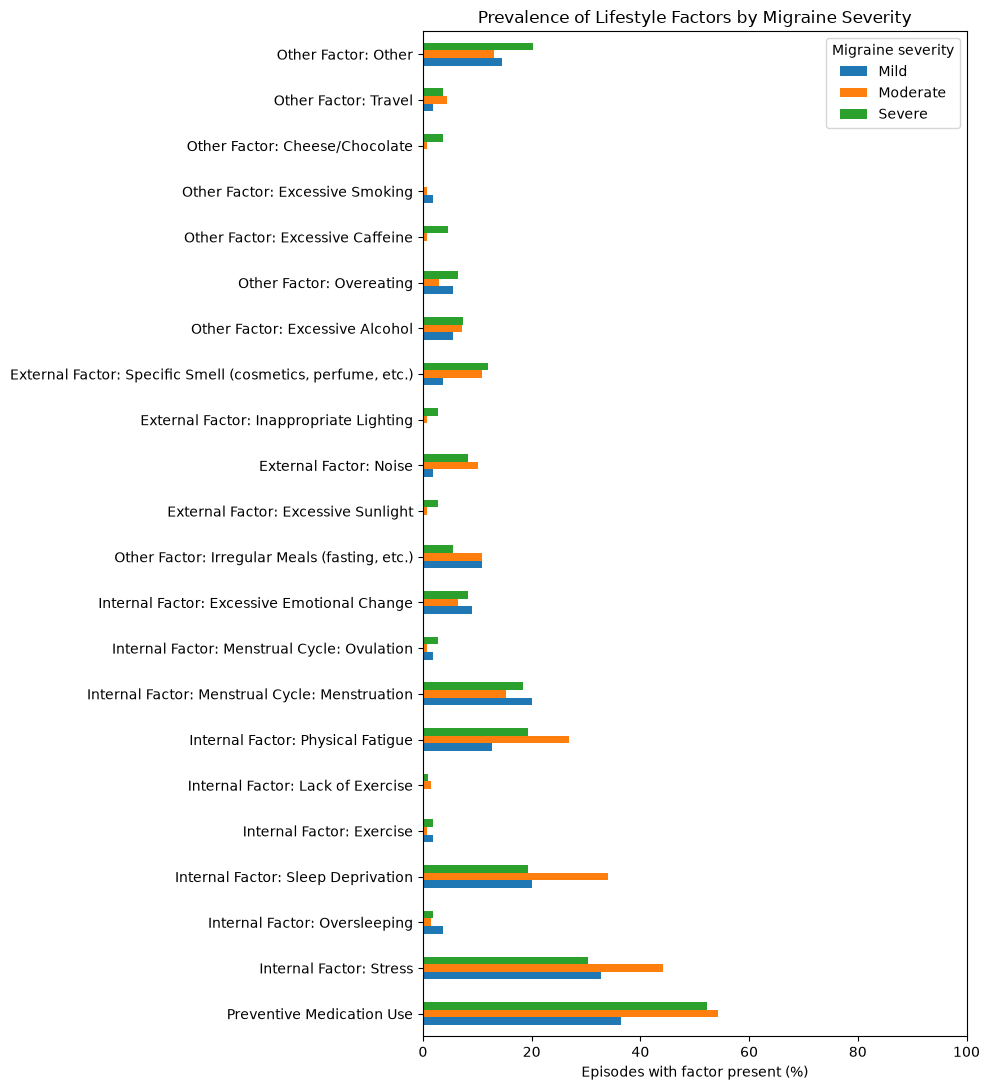

,Mild,Moderate,Severe
Feature,,,
Preventive Medication Use,36.36,54.35,52.29
Internal Factor: Stress,32.73,44.20,30.28
Internal Factor: Oversleeping,3.64,1.45,1.83
Internal Factor: Sleep Deprivation,20.00,34.06,19.27
Internal Factor: Exercise,1.82,0.72,1.83
Internal Factor: Lack of Exercise,0.00,1.45,0.92
Internal Factor: Physical Fatigue,12.73,26.81,19.27
Internal Factor: Menstrual Cycle: Menstruation,20.00,15.22,18.35
Internal Factor: Menstrual Cycle: Ovulation,1.82,0.72,2.75


In [20]:
binary_prevalence_wide = plot_grouped_binary_prevalence(
    data = model_df,
    variables = PHYSIOLOGICAL_BINARY_FEATURES + ENVIRONMENTAL_BINARY_FEATURES + LIFESTYLE_BINARY_FEATURES,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
    group_name = "Lifestyle Factors",
)

binary_prevalence_wide.round(2)

In [21]:
pd.crosstab(
    model_df["Severity_VAS"],
    model_df["Internal Factor: Stress"],
    normalize="index"
) * 100

Internal Factor: Stress,0,1
Severity_VAS,,
Mild,67.272727,32.727273
Moderate,55.797101,44.202899
Severe,69.724771,30.275229


In [22]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    model_df["Severity_VAS"],
    model_df["Internal Factor: Stress"]
)

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-square: {chi2:.2f}")
print(f"p-value: {p:.4f}")

Chi-square: 5.61
p-value: 0.0605


In [28]:
all_binary_features = (
    PHYSIOLOGICAL_BINARY_FEATURES
    + ENVIRONMENTAL_BINARY_FEATURES
    + LIFESTYLE_BINARY_FEATURES
)

# Analyze associations between binary features and migraine severity
binary_test_results = binary_crosstabs = analyze_binary_associations(
    data = model_df,
    variables = all_binary_features,
    target = TARGET,
    severity_order = SEVERITY_ORDER,
)

# Add Benjamini-Hochberg correction to the p-values
binary_test_results = add_benjamini_hochberg_correction(
    binary_test_results[0]
)

binary_test_results = (
    binary_test_results
    .sort_values(
        ["Adjusted P-Value", "P-Value"],
        na_position="last",
    )
    .reset_index(drop=True)
)

binary_test_results

,Feature,N,Chi-Square,Degrees of Freedom,P-Value,Cramers V,Minimum Expected Count,Expected Counts Below 5,Assumptions Met,Status,Adjusted P-Value,Significant After FDR
0,Internal Factor: Sleep Deprivation,302,8.218844,2,0.016417,0.164969,14.387417,0,True,Test completed,0.337933,False
1,Other Factor: Excessive Caffeine,302,6.028855,2,0.049074,0.141291,1.092715,3,False,Test completed,0.337933,False
2,Internal Factor: Stress,302,5.610585,2,0.060489,0.136301,20.397351,0,True,Test completed,0.337933,False
3,Preventive Medication Use,302,5.350735,2,0.068882,0.133108,27.317881,0,True,Test completed,0.337933,False
4,Internal Factor: Physical Fatigue,302,5.133026,2,0.076803,0.130372,11.837748,0,True,Test completed,0.337933,False
5,Other Factor: Cheese/Chocolate,302,4.376190,2,0.112130,0.120377,0.910596,3,False,Test completed,0.411144,False
6,External Factor: Noise,302,3.749673,2,0.153380,0.111428,4.370861,1,True,Test completed,0.482051,False
7,"External Factor: Specific Smell (cosmetics, pe...",302,3.056768,2,0.216886,0.100607,5.463576,0,True,Test completed,0.537552,False
8,External Factor: Excessive Sunlight,302,2.818376,2,0.244342,0.096604,0.728477,3,False,Test completed,0.537552,False
9,External Factor: Inappropriate Lighting,302,2.818376,2,0.244342,0.096604,0.728477,3,False,Test completed,0.537552,False


In [31]:
feature_to_group = {
    feature: group_name
    for group_name, feature_list in {
        "Physiological": PHYSIOLOGICAL_BINARY_FEATURES,
        "Environmental": ENVIRONMENTAL_BINARY_FEATURES,
        "Lifestyle": LIFESTYLE_BINARY_FEATURES,
    }.items()
    for feature in feature_list
}

if "Feature Group" not in binary_test_results.columns:
    binary_test_results.insert(
        1,
        "Feature Group",
        binary_test_results["Feature"].map(
            feature_to_group
        ),
    )
else:
    binary_test_results["Feature Group"] = binary_test_results["Feature"].map(feature_to_group)

binary_test_results[
    [
        "Feature",
        "Feature Group",
        "N",
        "Chi-Square",
        "P-Value",
        "Adjusted P-Value",
        "Cramers V",
        "Assumptions Met",
        "Significant After FDR",
    ]
]

,Feature,Feature Group,N,Chi-Square,P-Value,Adjusted P-Value,Cramers V,Assumptions Met,Significant After FDR
0,Internal Factor: Sleep Deprivation,Physiological,302,8.218844,0.016417,0.337933,0.164969,True,False
1,Other Factor: Excessive Caffeine,Lifestyle,302,6.028855,0.049074,0.337933,0.141291,False,False
2,Internal Factor: Stress,Physiological,302,5.610585,0.060489,0.337933,0.136301,True,False
3,Preventive Medication Use,Physiological,302,5.350735,0.068882,0.337933,0.133108,True,False
4,Internal Factor: Physical Fatigue,Physiological,302,5.133026,0.076803,0.337933,0.130372,True,False
5,Other Factor: Cheese/Chocolate,Lifestyle,302,4.376190,0.112130,0.411144,0.120377,False,False
6,External Factor: Noise,Environmental,302,3.749673,0.153380,0.482051,0.111428,True,False
7,"External Factor: Specific Smell (cosmetics, pe...",Environmental,302,3.056768,0.216886,0.537552,0.100607,True,False
8,External Factor: Excessive Sunlight,Environmental,302,2.818376,0.244342,0.537552,0.096604,False,False
9,External Factor: Inappropriate Lighting,Environmental,302,2.818376,0.244342,0.537552,0.096604,False,False
